In [10]:
import os
import sys
from pathlib import Path

root_dir = str(Path(os.getcwd()).parent)

if root_dir not in sys.path:
    sys.path.append(root_dir)

output_dir = "Outputs"
os.makedirs(output_dir, exist_ok=True)

<div style="background-color: #217de0; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0; color: #29007b; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">Incompressible Navier-Stokes Solvers </h1>
<p style="margin: 5px 0 0 0; color: #d0e6ff; font-size: 1.2em;">Real-Time High-Fidelity Eulerian Fluid Simulation via Operator Splitting</p>
</div>

Imports:

In [11]:
import numpy as np
from IPython.display import Video, HTML

from Solver.Stable_fluids_class import FluidSolver
from Utilities.visualizations import *

---

## Incompressible Fluid Dynamics

This framework tracks the evolution of an incompressible velocity field $\mathbf{u} = (u, v)$ and a transported density field (like dye or smoke) governed by the transient **Navier-Stokes Equations**:

$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} = -\frac{1}{\rho}\nabla p + \nu \nabla^2 \mathbf{u} + \mathbf{f}$$
$$\nabla \cdot \mathbf{u} = 0$$

To bypass strict CFL stability constraints that typically crash standard explicit solvers, this implementation utilizes **Jos Stam's Stable Fluids** fractional-step operator splitting pipeline:

1. **Add Forces:** Applies external velocity and density inputs (e.g., a continuous dye source).
2. **Advection:** Solves the non-linear transport using an unconditionally stable **Semi-Lagrangian Back-Tracing Scheme**.
3. **Diffusion:** Handles viscous friction and dye diffusion using a stable implicit linear system.
4. **Projection:** Enforces the divergence-free mass conservation constraint ($\nabla \cdot \mathbf{u} = 0$) by computing a scalar Poisson pressure field and subtracting its gradient from the velocity.

---

### Defining the Domain & Conditions:

Forcing Term:

In [12]:
def force(t, X, Y, a):

    force_field = np.zeros(X.shape + (2,))

    region = ((X > 7-0.7) & (X < 7) &
              (Y > 7/2-0.3) & (Y < 7/2+0.3))

    force_field[region, 0] = -12
    force_field[region, 1] = 3

    return force_field

General Parameters:

In [13]:
H  = 7
N  = 230
dt = 0.1
T  = 10
KINEMATIC_VISCOSITY = 0.001

Grid:

In [14]:
x, y = np.linspace(0, H, N), np.linspace(0, H, N)
X, Y = np.meshgrid(x, y, indexing='ij')
COORDINATES = np.stack((X, Y), axis=-1)
dx = H / (N - 1)

Defining Obstacle Mask:

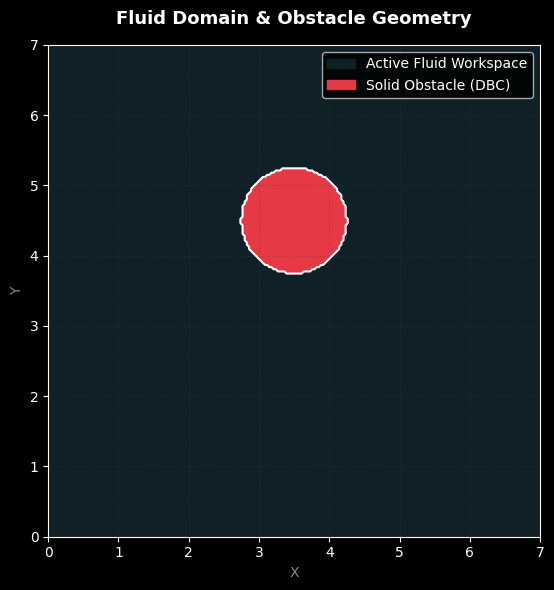

In [18]:
obstacle_mask = ((np.linspace(0,7,230)[:,None] - 3.5)**2 +
                 (np.linspace(0,7,230)[None,:] - 4.5)**2) < 0.75**2

obstacle_visual = os.path.join(output_dir, "obstacle_visual.jpeg")
sketch_obstacle(X, Y, obstacle_mask, H,
                save_path=obstacle_visual)

In [16]:
solver = FluidSolver(
    H=H,
    N=N,
    dt=dt,
    T=T,
    KINEMATIC_VISCOSITY=KINEMATIC_VISCOSITY,
    force_function=force,
    obstacle_mask=obstacle_mask
)

# Initial Condition
w0 = np.zeros((N, N, 2))

print(f"Solver initialized: grid {N}x{N}, dt={dt}, T={T}")

Solver initialized: grid 230x230, dt=0.1, T=10
